In [1]:
import cleaning as cl
import pandas as pd
from sklearn.model_selection import train_test_split
import sys

In [2]:
pd.set_option("display.max_columns", None)

data = pd.read_csv("../../data/raw/king_ country_ houses_aa.csv")
data = data[data.bedrooms < 33]
data.head()

X = data.drop(['price', "id"], axis=1)
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=X.waterfront, random_state=42)
assert len(set(X_train.zipcode)) == len(set(data.zipcode))

zipcode_ranking_map = cl.create_zipcode_ranking_map(X_train, y_train)


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

X_train_cleaned = cl.preprocess_features(X_train, zipcode_ranking_map)
X_test_cleaned = cl.preprocess_features(X_test, zipcode_ranking_map)

lm = LinearRegression()
lm.fit(X_train_cleaned, y_train)

train_pred = lm.predict(X_train_cleaned)
test_pred = lm.predict(X_test_cleaned)

print("Train Score")
print(root_mean_squared_error(y_train, train_pred))
print(r2_score(y_train, train_pred))

print()
print("Test Score")
print(root_mean_squared_error(y_test, test_pred))
print(r2_score(y_test, test_pred))

Train Score
190559.92313036596
0.7288568142120295

Test Score
191484.1488117862
0.7346978898743987


### Baseline Model: Linear Regression

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

X_train_cleaned = cl.preprocess_features(X_train, zipcode_ranking_map)
X_test_cleaned = cl.preprocess_features(X_test, zipcode_ranking_map)

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train_cleaned, y_train)

# Predictions
y_train_pred = lr.predict(X_train_cleaned)
y_test_pred = lr.predict(X_test_cleaned)

# Evaluate performance
print("---- Train Performance ----")
print(f"R²:   {r2_score(y_train, y_train_pred):.4f}")
print(f"RMSE: ${root_mean_squared_error(y_train, y_train_pred):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_train, y_train_pred):,.2f}")

print("\n---- Test Performance ----")
print(f"R²:   {r2_score(y_test, y_test_pred):.4f}")
print(f"RMSE: ${root_mean_squared_error(y_test, y_test_pred):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_test, y_test_pred):,.2f}")

---- Train Performance ----
R²:   0.7289
RMSE: $190,559.92
MAE:  $111,214.17

---- Test Performance ----
R²:   0.7347
RMSE: $191,484.15
MAE:  $112,553.81


### Random Forest

In [5]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_cleaned, y_train)

# Predictions
y_train_pred = rf.predict(X_train_cleaned)
y_test_pred = rf.predict(X_test_cleaned)

# Evaluate performance
print("---- Train Performance ----")
print(f"R²:   {r2_score(y_train, y_train_pred):.4f}")
print(f"RMSE: ${root_mean_squared_error(y_train, y_train_pred):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_train, y_train_pred):,.2f}")

print("\n---- Test Performance ----")
print(f"R²:   {r2_score(y_test, y_test_pred):.4f}")
print(f"RMSE: ${root_mean_squared_error(y_test, y_test_pred):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_test, y_test_pred):,.2f}")

---- Train Performance ----
R²:   0.9832
RMSE: $47,421.01
MAE:  $25,967.19

---- Test Performance ----
R²:   0.8822
RMSE: $127,574.35
MAE:  $69,338.78


### XGBoost

In [6]:
from xgboost import XGBRegressor

# Train XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb.fit(X_train_cleaned, y_train)

# Predictions
y_train_pred = xgb.predict(X_train_cleaned)
y_test_pred = xgb.predict(X_test_cleaned)

# Evaluate performance
print("---- Train Performance ----")
print(f"R²:   {r2_score(y_train, y_train_pred):.4f}")
print(f"RMSE: ${root_mean_squared_error(y_train, y_train_pred):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_train, y_train_pred):,.2f}")

print("\n---- Test Performance ----")
print(f"R²:   {r2_score(y_test, y_test_pred):.4f}")
print(f"RMSE: ${root_mean_squared_error(y_test, y_test_pred):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_test, y_test_pred):,.2f}")

---- Train Performance ----
R²:   0.9778
RMSE: $54,520.23
MAE:  $39,252.28

---- Test Performance ----
R²:   0.8859
RMSE: $125,561.59
MAE:  $68,041.92


### Ensemble: Stacking

- Layer 1 (Base models): RandomForest, XGBoost and Gradient Boosting each make predictions independently
- Layer 2 (Meta-model): Linear Regression learns how to best combine those predictions into a final output
- cv = 5  base models are trained using 5-fold cross-validation to prevent leakage into the meta-model

In [7]:
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

# Base models
base_models = [
    ("random_forest", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ("xgboost", XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ("gradient_boosting", GradientBoostingRegressor(n_estimators=100, random_state=42))
]

# Meta-model
meta_model = LinearRegression()

# Train Stacking Model
stacking = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)
stacking.fit(X_train_cleaned, y_train)

# Predictions
y_train_pred = stacking.predict(X_train_cleaned)
y_test_pred = stacking.predict(X_test_cleaned)

# Evaluate performance
print("---- Train Performance ----")
print(f"R²:   {r2_score(y_train, y_train_pred):.4f}")
print(f"RMSE: ${root_mean_squared_error(y_train, y_train_pred):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_train, y_train_pred):,.2f}")

print("\n---- Test Performance ----")
print(f"R²:   {r2_score(y_test, y_test_pred):.4f}")
print(f"RMSE: ${root_mean_squared_error(y_test, y_test_pred):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_test, y_test_pred):,.2f}")

---- Train Performance ----
R²:   0.9607
RMSE: $72,502.57
MAE:  $48,372.03

---- Test Performance ----
R²:   0.8959
RMSE: $119,958.32
MAE:  $66,747.30


### CatBoost

In [8]:
from catboost import CatBoostRegressor

# zipcode is already encoded as zipcode_ordinal_rank by cl.preprocess_features()
cat_features = ["waterfront", "view", "condition"]

# Train CatBoost using cleaned data
catboost = CatBoostRegressor(
    iterations=100,
    random_seed=42,
    verbose=False
)
catboost.fit(X_train_cleaned, y_train, cat_features=cat_features)

# Predictions
y_train_pred = catboost.predict(X_train_cleaned)
y_test_pred = catboost.predict(X_test_cleaned)

# Evaluate performance
print("---- Train Performance ----")
print(f"R²:   {r2_score(y_train, y_train_pred):.4f}")
print(f"RMSE: ${root_mean_squared_error(y_train, y_train_pred):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_train, y_train_pred):,.2f}")

print("\n---- Test Performance ----")
print(f"R²:   {r2_score(y_test, y_test_pred):.4f}")
print(f"RMSE: ${root_mean_squared_error(y_test, y_test_pred):,.2f}")
print(f"MAE:  ${mean_absolute_error(y_test, y_test_pred):,.2f}")

---- Train Performance ----
R²:   0.9514
RMSE: $80,636.37
MAE:  $55,009.28

---- Test Performance ----
R²:   0.8975
RMSE: $119,007.42
MAE:  $67,710.06


### Comparative

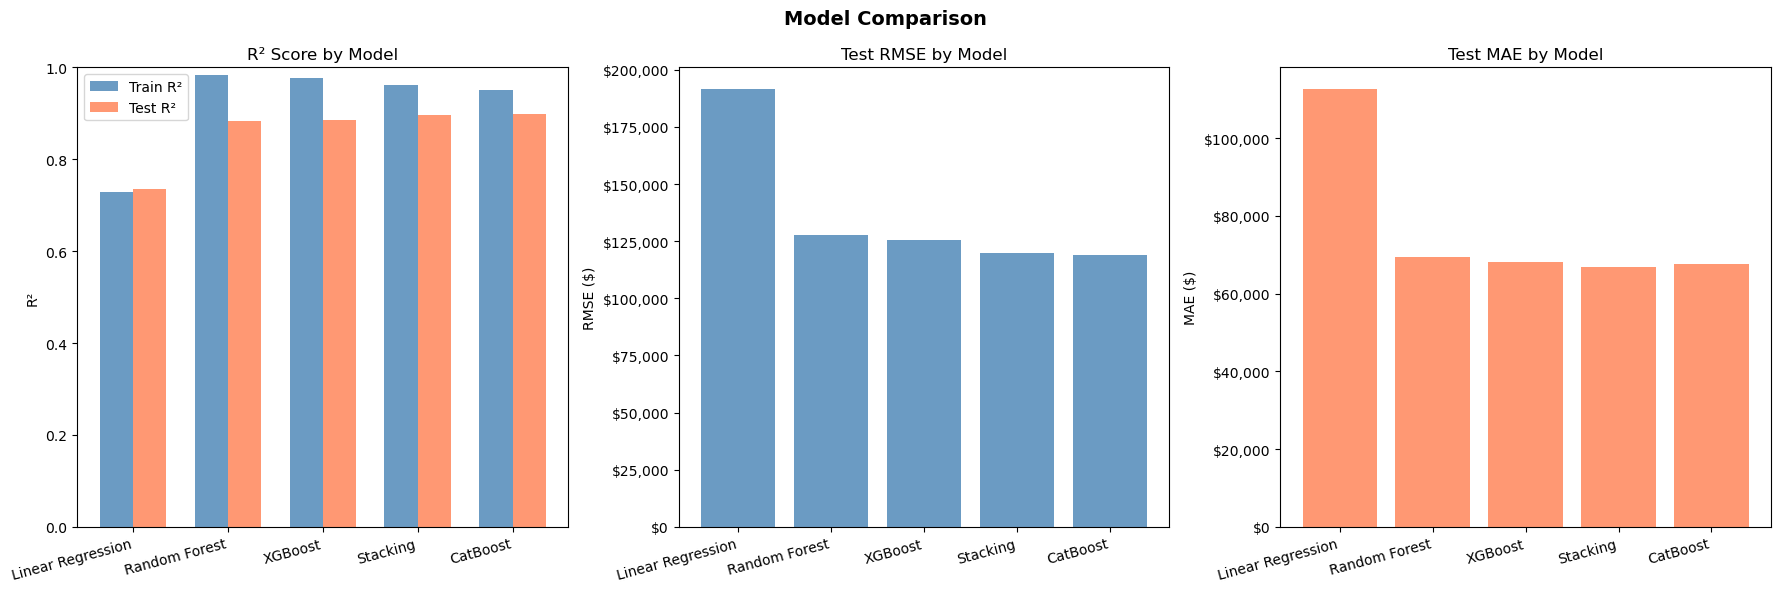

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Model results
models = ["Linear Regression", "Random Forest", "XGBoost", "Stacking", "CatBoost"]

train_r2  = [r2_score(y_train, lr.predict(X_train_cleaned)),
             r2_score(y_train, rf.predict(X_train_cleaned)),
             r2_score(y_train, xgb.predict(X_train_cleaned)),
             r2_score(y_train, stacking.predict(X_train_cleaned)),
             r2_score(y_train, catboost.predict(X_train_cleaned))]

test_r2   = [r2_score(y_test, lr.predict(X_test_cleaned)),
             r2_score(y_test, rf.predict(X_test_cleaned)),
             r2_score(y_test, xgb.predict(X_test_cleaned)),
             r2_score(y_test, stacking.predict(X_test_cleaned)),
             r2_score(y_test, catboost.predict(X_test_cleaned))]

test_rmse = [root_mean_squared_error(y_test, lr.predict(X_test_cleaned)),
             root_mean_squared_error(y_test, rf.predict(X_test_cleaned)),
             root_mean_squared_error(y_test, xgb.predict(X_test_cleaned)),
             root_mean_squared_error(y_test, stacking.predict(X_test_cleaned)),
             root_mean_squared_error(y_test, catboost.predict(X_test_cleaned))]

test_mae  = [mean_absolute_error(y_test, lr.predict(X_test_cleaned)),
             mean_absolute_error(y_test, rf.predict(X_test_cleaned)),
             mean_absolute_error(y_test, xgb.predict(X_test_cleaned)),
             mean_absolute_error(y_test, stacking.predict(X_test_cleaned)),
             mean_absolute_error(y_test, catboost.predict(X_test_cleaned))]

x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# R2 comparison
axes[0].bar(x - width/2, train_r2, width, label="Train R²", color="steelblue", alpha=0.8)
axes[0].bar(x + width/2, test_r2,  width, label="Test R²",  color="coral",     alpha=0.8)
axes[0].set_title("R² Score by Model")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15, ha="right")
axes[0].set_ylabel("R²")
axes[0].set_ylim(0, 1)
axes[0].legend()

# RMSE comparison
axes[1].bar(models, test_rmse, color="steelblue", alpha=0.8)
axes[1].set_title("Test RMSE by Model")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15, ha="right")
axes[1].set_ylabel("RMSE ($)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# MAE comparison
axes[2].bar(models, test_mae, color="coral", alpha=0.8)
axes[2].set_title("Test MAE by Model")
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=15, ha="right")
axes[2].set_ylabel("MAE ($)")
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.suptitle("Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

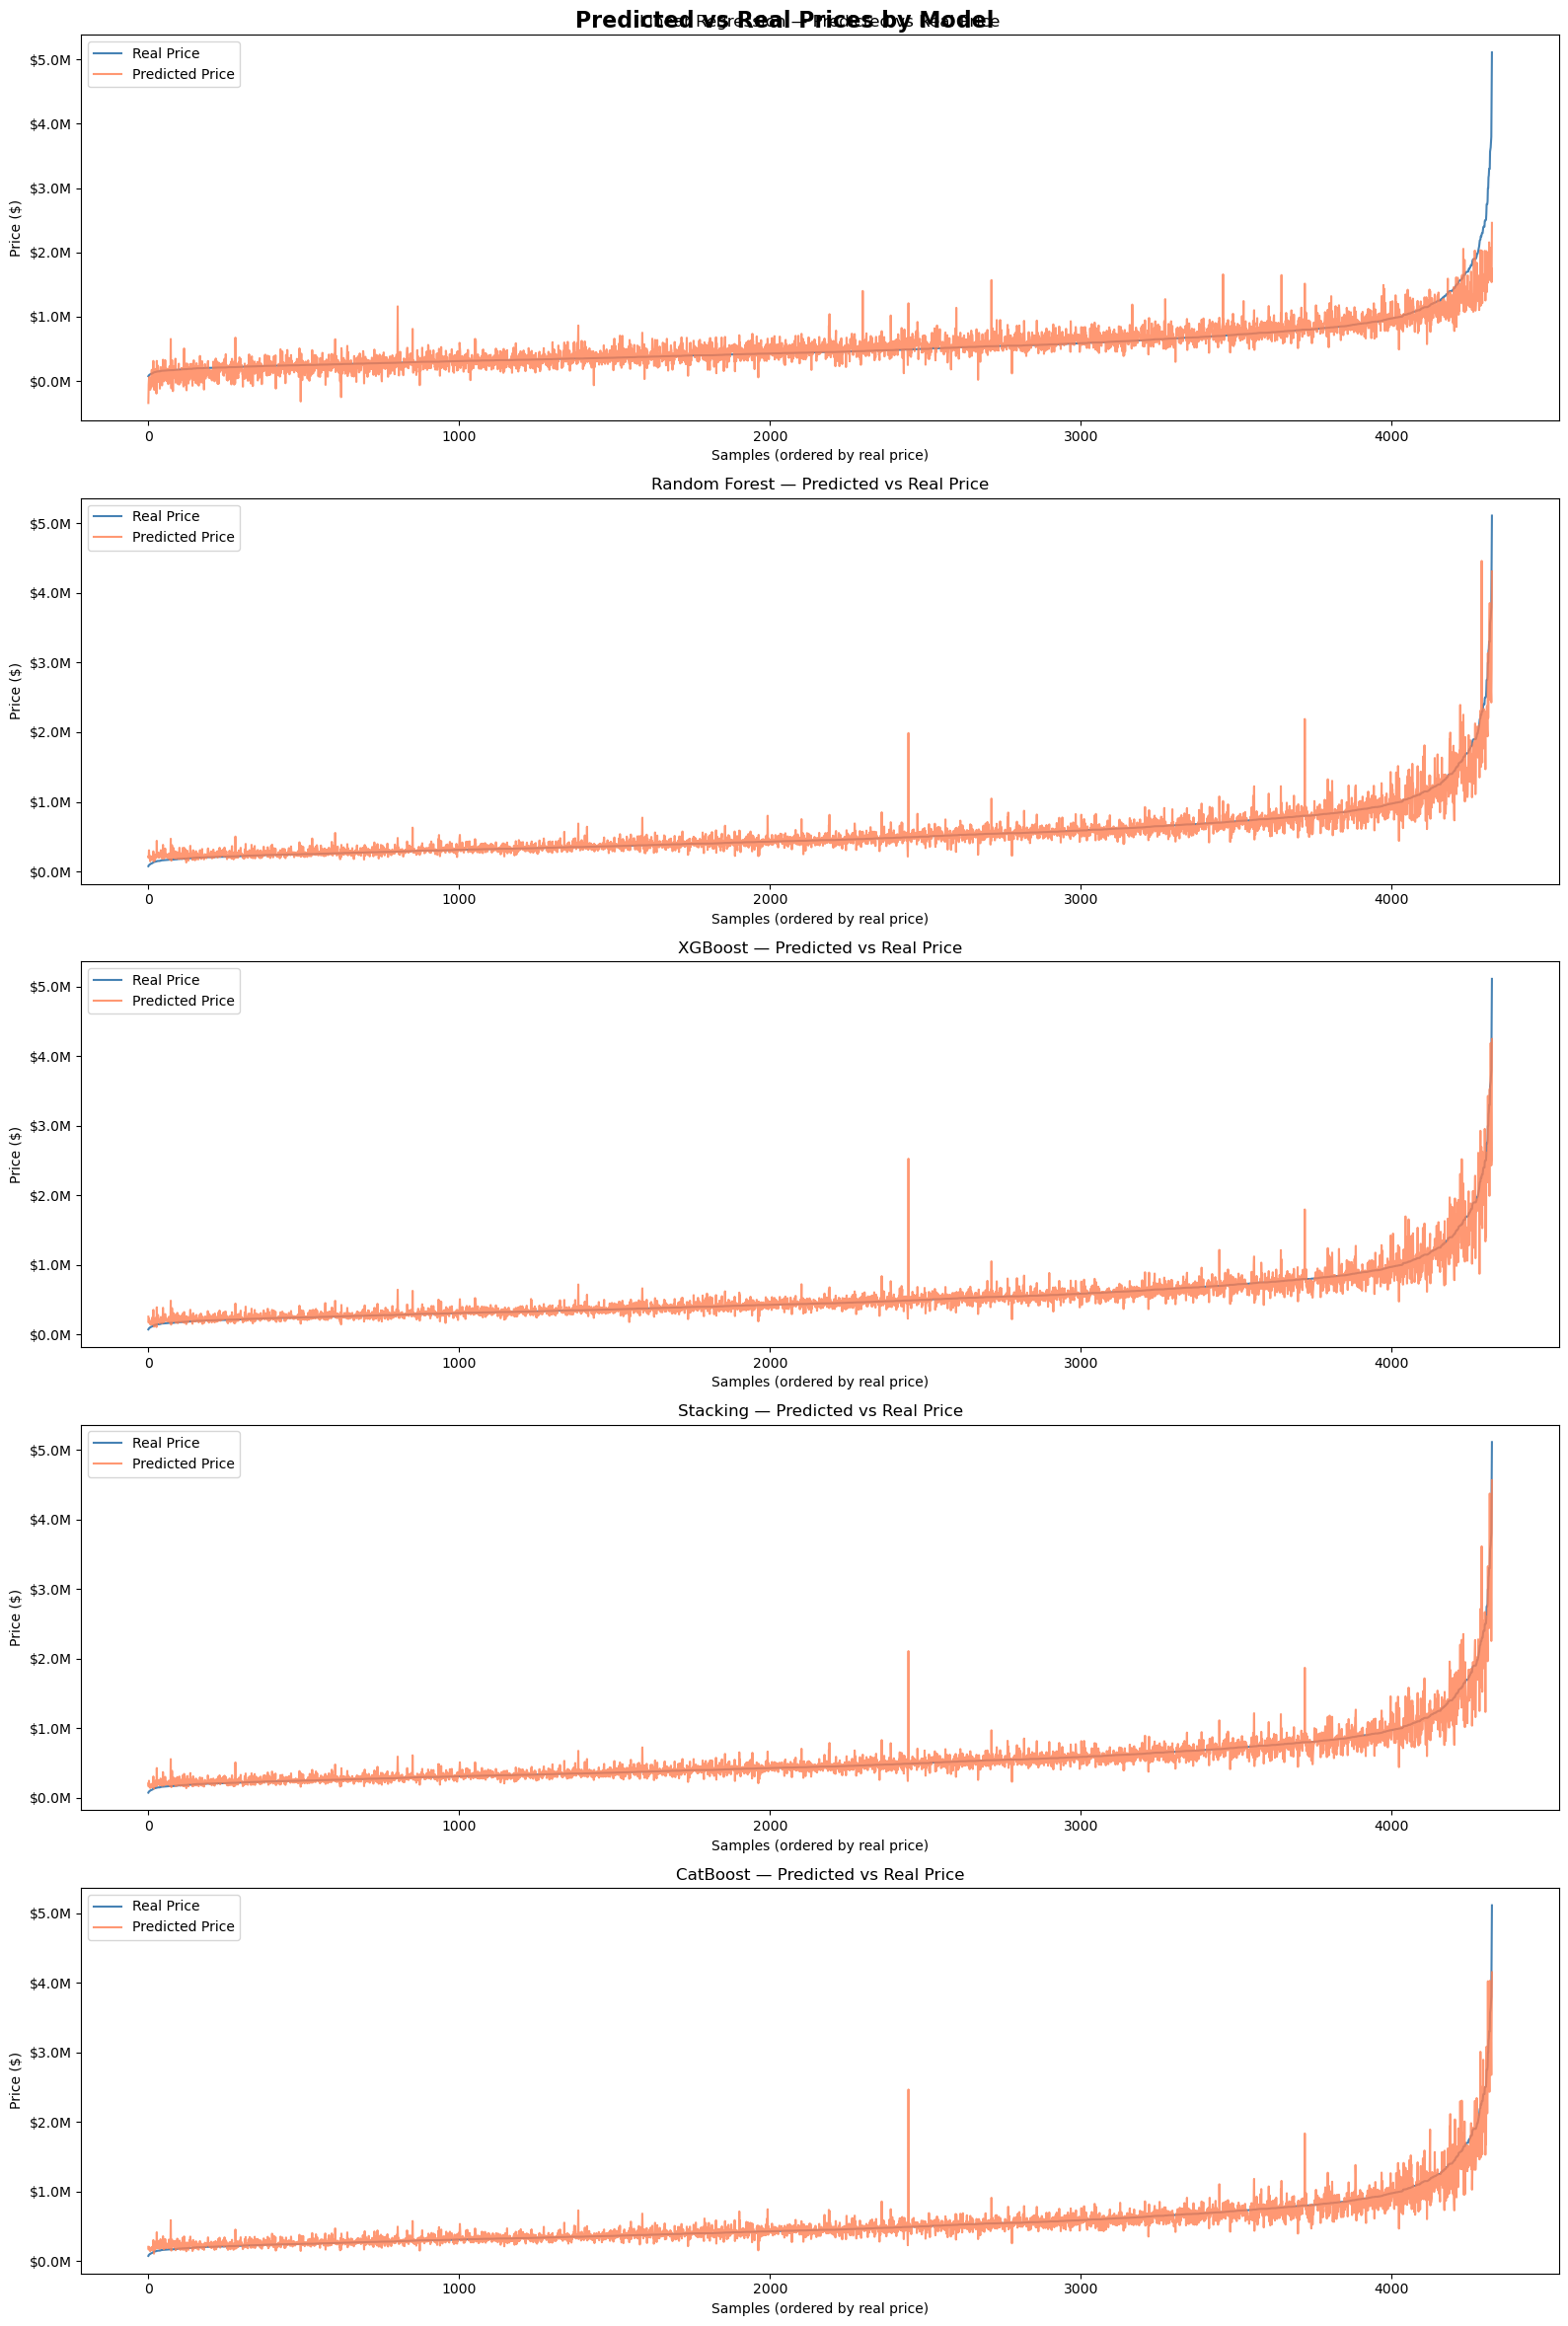

In [10]:
fig, axes = plt.subplots(5, 1, figsize=(16, 24))

model_names = ["Linear Regression", "Random Forest", "XGBoost", "Stacking", "CatBoost"]
predictions = [
    lr.predict(X_test_cleaned),
    rf.predict(X_test_cleaned),
    xgb.predict(X_test_cleaned),
    stacking.predict(X_test_cleaned),
    catboost.predict(X_test_cleaned)
]

for ax, name, y_pred in zip(axes, model_names, predictions):
    # Sort by real price
    sorted_indices = np.argsort(y_test.values)
    real_sorted = y_test.values[sorted_indices]
    pred_sorted = y_pred[sorted_indices]
    x_range = np.arange(len(real_sorted))

    ax.plot(x_range, real_sorted, color="steelblue", label="Real Price",      linewidth=1.5)
    ax.plot(x_range, pred_sorted, color="coral",     label="Predicted Price", linewidth=1.5, alpha=0.8)
    ax.set_title(f"{name} — Predicted vs Real Price")
    ax.set_xlabel("Samples (ordered by real price)")
    ax.set_ylabel("Price ($)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
    ax.legend()

plt.suptitle("Predicted vs Real Prices by Model", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()